In [110]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
df = pd.read_csv('student.csv')

In [112]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   study_hours            10000 non-null  int64  
 1   attendance             10000 non-null  int64  
 2   sleep_hours            10000 non-null  int64  
 3   internet_usage         10000 non-null  int64  
 4   assignments_completed  10000 non-null  int64  
 5   previous_score         10000 non-null  int64  
 6   exam_score             10000 non-null  float64
 7   placement_status       10000 non-null  str    
dtypes: float64(1), int64(6), str(1)
memory usage: 690.1 KB


In [113]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,Placed
1,4,69,5,3,8,56,100.00,Placed
2,11,60,7,6,10,45,100.00,Placed
3,8,99,9,8,4,55,90.17,Placed
4,5,52,8,6,8,40,78.82,Placed


In [114]:
# placement_status'u değişcez: Placed / Not Placed

df['placement_status'] = df['placement_status'].apply(lambda x: 1 if x == 'Placed' else 0)


In [115]:
df.head()

,study_hours,attendance,sleep_hours,internet_usage,assignments_completed,previous_score,exam_score,placement_status
0,7,56,8,7,10,62,100.00,1
1,4,69,5,3,8,56,100.00,1
2,11,60,7,6,10,45,100.00,1
3,8,99,9,8,4,55,90.17,1
4,5,52,8,6,8,40,78.82,1


<Axes: xlabel='study_hours', ylabel='exam_score'>

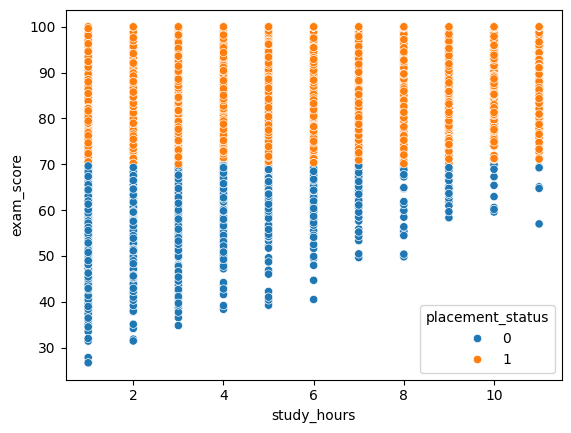

In [116]:
sns.scatterplot(x = df['study_hours'], y = df['exam_score'], hue = df['placement_status'])

<Axes: xlabel='sleep_hours', ylabel='exam_score'>

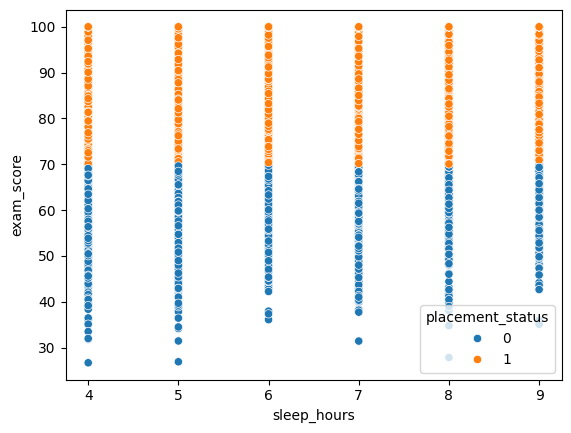

In [117]:
sns.scatterplot(x = df['sleep_hours'], y = df['exam_score'], hue = df['placement_status'])

In [118]:
# 70 puan ve üzeri alan öğrencilerin yerleşme olasılığı daha yüksek görünüyor.
# Attendance, sleep_hours ve study_hours'ın da yerleşme üzerinde etkisi olabilir, ancak exam_score'un daha belirgin bir etkisi var gibi görünüyor.

In [119]:
X = df[['study_hours', 'sleep_hours', 'attendance', 'exam_score']].values
y = df['placement_status'].values

In [120]:
from sklearn.model_selection import train_test_split

In [121]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# X'leri float32 tensor'a çeviriyoruz - PyTorch float64 istemez
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

# y'leri de float32 tensor'a çevirmeliyiz!
# BCEWithLogitsLoss hem input hem target'ın tensor olmasını ve float32 olmasını bekliyor.
# int64 (numpy default) verirsen "int object is not callable" hatası alırsın.
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [123]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([8000, 4]) torch.Size([8000])
torch.Size([2000, 4]) torch.Size([2000])


In [124]:
class StudentScores(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(4, 1)
        # 1 katmanlı yaptık çünkü veri setimiz küçük ve basit, daha karmaşık bir model overfitting yapabilir.

    def forward(self, x):
        return self.linear(x)

In [125]:
model = StudentScores()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.01)

In [126]:
def calculate_accuracy(y_pred, y_true):
    correct = torch.eq(y_pred, y_true).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc

In [127]:
# Binary classification (0 veya 1) → sigmoid kullanılır, softmax değil!
# Softmax: çok sınıflı problemlerde tüm çıktıların toplamını 1'e normalize eder
# Sigmoid: tek bir değeri 0-1 arasına sıkıştırır → "Placed olma olasılığı"
y_logits = model(X_test)
y_pred_probs = torch.sigmoid(y_logits)
print(f"Logit örneği: {y_logits[0].item():.4f} → Sigmoid sonrası: {y_pred_probs[0].item():.4f}")

Logit örneği: 0.0718 → Sigmoid sonrası: 0.5179


In [128]:
epochs = 300

train_loss_values = []
train_acc_values = []
test_loss_values = []
test_acc_values = []

for epoch in range(epochs):

    model.train()

    logits = model(X_train)
    # logits shape: [8000, 1] — ama y_train shape: [8000]
    # .squeeze() ile [8000, 1] → [8000] yapıyoruz, shape eşleşmeli
    loss = loss_fn(logits.squeeze(), y_train)

    # BCEWithLogitsLoss içinde zaten sigmoid var, ayrıca uygulamamak gerekiyor.
    # Ama tahmin için (prediction) sigmoid'i manuel uyguluyoruz:
    # sigmoid(logit) >= 0.5 ise "Placed" (1), değilse "Not Placed" (0)
    pred = (torch.sigmoid(logits.squeeze()) >= 0.5).float()
    acc = calculate_accuracy(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_loss_values.append(loss.item())
    train_acc_values.append(acc)
    
    model.eval()
    with torch.inference_mode():
        test_logits = model(X_test).squeeze()  # aynı shape düzeltmesi
        test_loss = loss_fn(test_logits, y_test)

        # Burada da sigmoid uygulamalıyız! Raw logit üzerine 0.5 threshold yanlış.
        # Sigmoid → olasılık → 0.5 threshold → sınıf kararı
        test_pred = (torch.sigmoid(test_logits) >= 0.5).float()
        test_acc = calculate_accuracy(test_pred, y_test)

        test_loss_values.append(test_loss.item())
        test_acc_values.append(test_acc)

        if epoch % 50 == 0:
            print(f"Epoch: {epoch:3d} | Train Loss: {loss:.4f} | Train Acc: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}%")

Epoch:   0 | Train Loss: 0.7102 | Train Acc: 57.55% | Test Loss: 0.6958 | Test Acc: 58.20%
Epoch:  50 | Train Loss: 0.4180 | Train Acc: 87.04% | Test Loss: 0.4145 | Test Acc: 87.15%
Epoch: 100 | Train Loss: 0.3031 | Train Acc: 92.86% | Test Loss: 0.3035 | Test Acc: 92.35%
Epoch: 150 | Train Loss: 0.2451 | Train Acc: 94.42% | Test Loss: 0.2473 | Test Acc: 94.30%
Epoch: 200 | Train Loss: 0.2087 | Train Acc: 95.58% | Test Loss: 0.2119 | Test Acc: 95.45%
Epoch: 250 | Train Loss: 0.1835 | Train Acc: 96.40% | Test Loss: 0.1872 | Test Acc: 96.35%


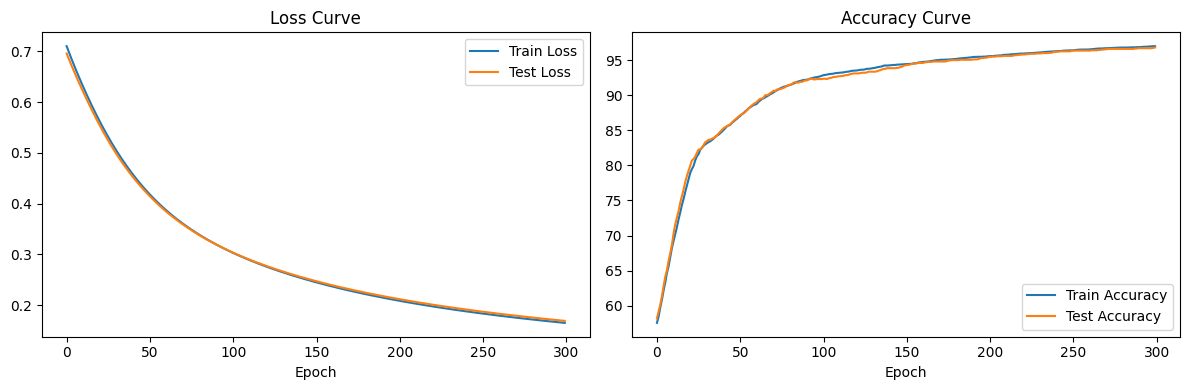

In [129]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(train_loss_values, label='Train Loss')
ax1.plot(test_loss_values, label='Test Loss')
ax1.set_title('Loss Curve')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(train_acc_values, label='Train Accuracy')
ax2.plot(test_acc_values, label='Test Accuracy')
ax2.set_title('Accuracy Curve')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()